## Librerias

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Librerias importadas correctamente")

Librerias importadas correctamente


## 1. Carga y exploración de datos

### 1.1 Cargar dataset en un DataFrame

In [9]:
df = pd.read_csv("StudentsPerformance.csv")
print("Datos cargados correctamente")

Datos cargados correctamente


### 1.2 Mostrar head(), info() y describe()

In [13]:
df.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


* 8 columnas, 1000 registros.

In [12]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### 1.3 Identificar variables y tipo de datos

Luego de realizar la carga del dataset y observar la estructura con `.info()` y `.describe()`, identificamos lo siguiente: 

* **Variables Categóricas Nominales:**
    * `gender`: Identifica el género del estudiante (male/female).
    * `race/ethnicity`: Grupos étnicos anonimizados (Group A, B, C, etc.).
    * `lunch`: Indica si el alumno recibe almuerzo estándar o reducido.
    * `test preparation course`: Variable binaria que indica si el alumno completó o no el curso de preparación.

* **Variables Categóricas Ordinales:**
    * `parental level of education`: Nivel educativo de los padres. Posee una jerarquía.

* **Variables Numéricas:**
    * `math score`: **Variable Objetivo (Target)**. Representa el puntaje en matemáticas
    * `reading score`: Puntaje en lectura
    * `writing score`: Puntaje en escritura

## 2. Preprocesamiento

### 2.1 Verificar valores faltantes

In [14]:
nulos = df.isnull().sum()
print(f"Total de filas nulas: \n{nulos}")

Total de filas nulas: 
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [15]:
duplicados = df.duplicated().sum()
print(f"Total de filas duplicadas: {duplicados}")

Total de filas duplicadas: 0


### 2.2 Dividir datos en entrenamiento (80%) y prueba (20%)

In [17]:
#Separamos la variable objetivo (y) de las predictoras (X)
X = df.drop('math score', axis=1)
y = df['math score']

#Dividimos datos 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [18]:
#Verificamos las dimensiones
print(f"Registros totales: {len(df)}")
print(f"Entrenamiento: {len(X_train)}")
print(f"Prueba: {len(X_test)}")

Registros totales: 1000
Entrenamiento: 800
Prueba: 200


## 3. Modelado

### 3.1 Entrenar un modelo

In [20]:
#Definimos qué columnas son categóricas para transformarlas
categorical_features = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

#Creamos un transformador para convertir texto a números (OneHotEncoding)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ], remainder='passthrough')

#Creamos un Pipeline que primero procesa los datos y luego entrena el modelo
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

#Entrenamos el modelo
model.fit(X_train, y_train)

print("Modelo entrenado exitosamente.")

Modelo entrenado exitosamente.


### 3.2 Justificar la elección del modelo

* He elegido un modelo de `Regresión` porque la variable objetivo (math score) es numérica. El objetivo es predecir un valor exacto, no clasificar al alumno en categorías.

## 4. Evaluación e interpretación

### 4.1 Interpretar resultados

In [31]:
#Realizamos las predicciones con el conjunto de prueba
y_pred = model.predict(X_test)

#Calculamos las métricas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


MAE: 4.21
MSE: 29.10
RMSE: 5.39
R² Score: 0.88


* `MAE`: En promedio, el modelo se equivoca por unos 4.21 puntos en el examen de matemáticas.

* `MSE`: Al ser un número bajo en relación con la escala de 0 a 100, nos indica que el modelo es bastante estable y no tiene grandes errores en la mayoría de los datos.

* `RMSE`: Es la raíz del error anterior y nos da una "alerta" de calidad. Como el 5.39 es un poco más alto que el MAE (4.21), nos confirma que existen algunos alumnos específicos donde el modelo se equivocó por mucho más que el promedio.

* `R² Score`: Un 0.88 significa que el modelo logra explicar el 88% de la variabilidad de las notas de matemáticas.

### 4.2 Gráfico de dispersión

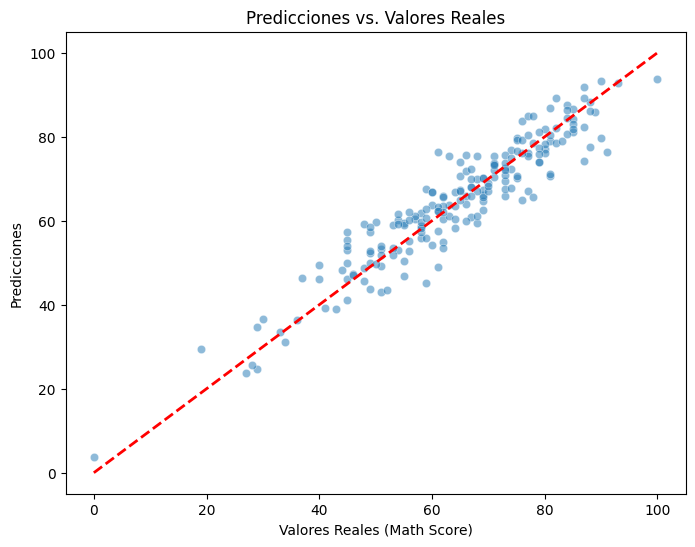

In [33]:
#Predicciones vs Reales
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Valores Reales (Math Score)')
plt.ylabel('Predicciones')
plt.title('Predicciones vs. Valores Reales')
plt.show()